In [33]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

In [34]:
df = pd.read_csv('diabetes.csv')

## About Dataset 
The dataset is part of a larger dataset held at the National Institutes of Diabetes-Digestive-Kidney Diseases in the US. In the US Pima Indian women aged 21 years and older living in Phoenix, the 5th largest city in the State of Arizona are the data used for diabetes research.

The target variable is specified as "outcome", where 1 indicates a positive diabetes test result and 0 indicates a negative result.

🤰Pregnancies: Number of pregnancies

🍬Glucose: 2-hour plasma glucose concentration in oral glucose tolerance test

🩸Blood Pressure: Blood Pressure (small blood pressure) (mm Hg)

⛄SkinThickness: Skin Thickness

❗Insulin: 2-hour serum insulin (mu U/ml)

⁉️DiabetesPedigreeFunction: Function (2-hour plasma glucose concentration in oral glucose tolerance test)

🧈BMI: Body mass index

👵Age: Age (years)

💉Outcome: Have the disease (1) or not (0)


In [35]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [36]:
df.shape

(768, 9)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [38]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [39]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

<Axes: xlabel='Outcome'>

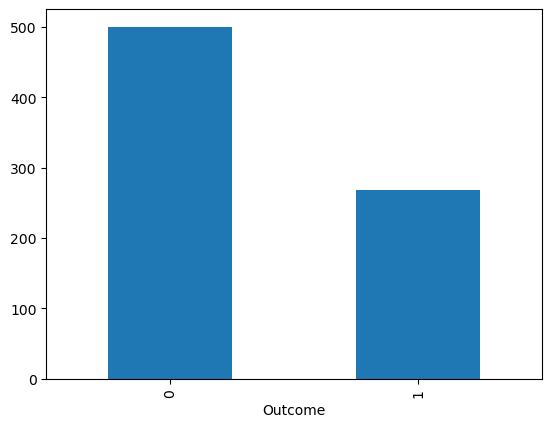

In [40]:
df['Outcome'].value_counts().plot(kind='bar')

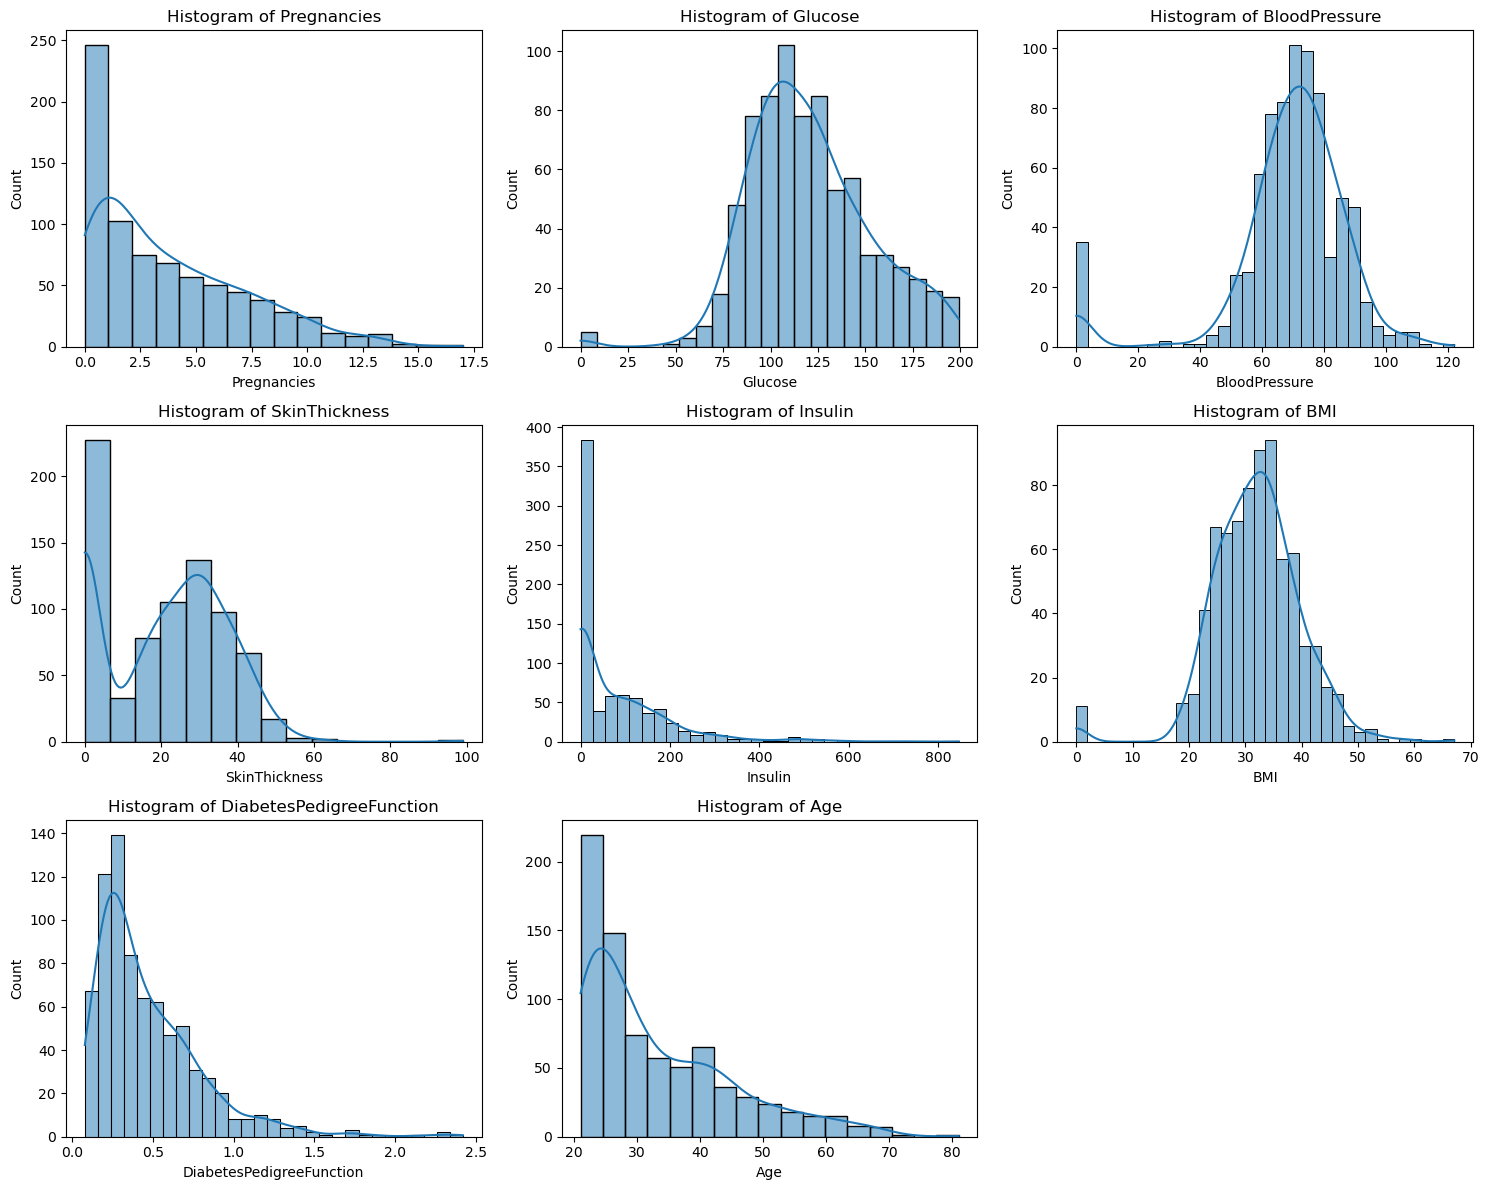

In [41]:
num_cols = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]
plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    
plt.tight_layout()

#### Data Quality Observations

* Glucose column contains 0 values, which are medically unrealistic and likely represent missing values.

* BloodPressure contains 0 values, which are invalid because a living person cannot have zero blood pressure.

* SkinThickness has 0 values that may indicate missing measurements.

* Insulin contains many 0 values, which are likely missing data rather than actual insulin measurements.

* BMI contains 0 values, which are impossible because BMI cannot be zero.

* DiabetesPedigreeFunction values ranging from 0 to 2.5 are considered valid.

In [42]:
gul_mean = df.loc[df['Glucose'] != 0 ,'Glucose'].mean()

In [43]:
df['Glucose'] = df['Glucose'].replace(0,gul_mean)
df['Glucose'] = df['Glucose'].round(2)

In [44]:
Bp_mean = df.loc[df['BloodPressure'] != 0 ,'BloodPressure'].mean()
df['BloodPressure'] = df['BloodPressure'].replace(0,Bp_mean)
df['BloodPressure'] = df['BloodPressure'].round(2)

In [45]:
St_mean = df.loc[df['SkinThickness'] != 0 ,'SkinThickness'].median()
df['SkinThickness'] = df['SkinThickness'].replace(0,St_mean)
df['SkinThickness'] = df['SkinThickness'].round(2)

In [46]:
Ins_mean = df.loc[df['Insulin'] != 0 ,'Insulin'].median()
df['Insulin'] = df['Insulin'].replace(0,Ins_mean)
df['Insulin'] = df['Insulin'].round(2)

In [47]:
BMI_mean = df.loc[df['BMI'] != 0 ,'BMI'].mean()
df['BMI'] = df['BMI'].replace(0,BMI_mean)
df['BMI'] = df['BMI'].round(2)


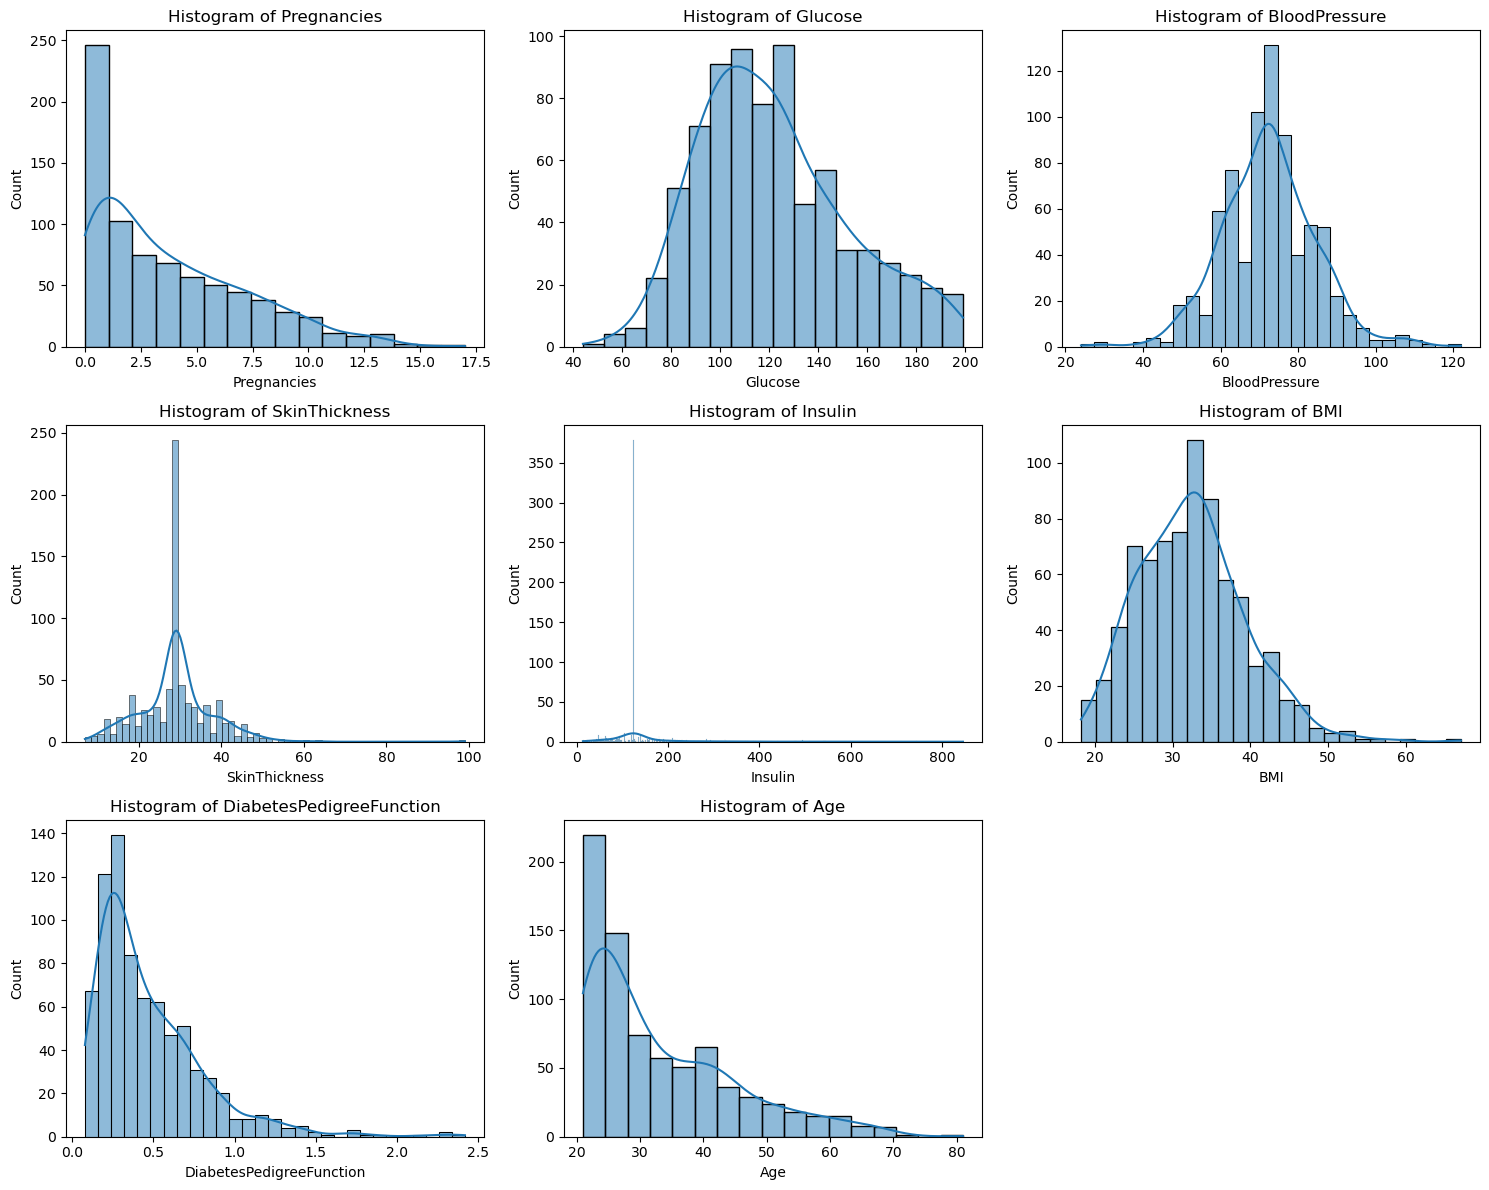

In [48]:
num_cols = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]
plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    
plt.tight_layout()

<Axes: >

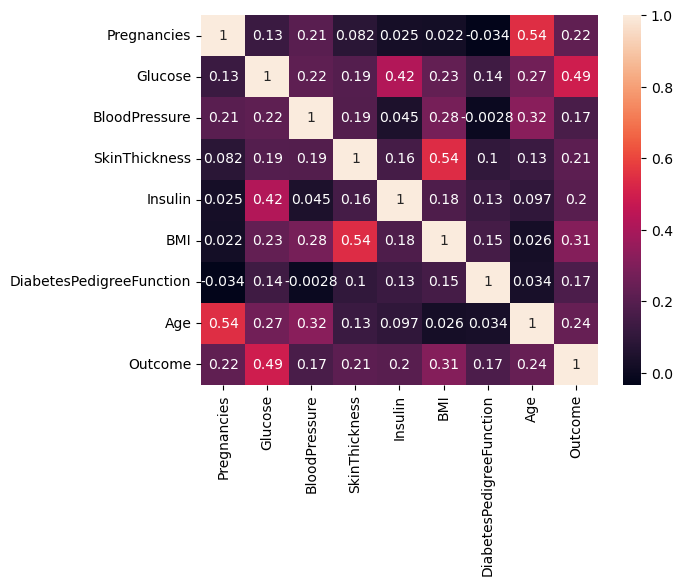

In [49]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

#### Heatmap Insights 
* Glucose has the strongest correlation with Outcome
This indicates that glucose level is strongly associated with diabetes prediction.
Higher glucose levels are more likely linked to diabetic patients.
* BMI shows moderate correlation with Outcome
This suggests that higher BMI may increase the likelihood of diabetes.
* Age has a positive relationship with Outcome
Older individuals may have a higher risk of diabetes.
* Pregnancies are positively correlated with Outcome
Increased number of pregnancies may slightly increase diabetes risk.
* Insulin has weak-to-moderate correlation with Outcome
Insulin alone may not strongly predict diabetes.
* SkinThickness has very weak correlation with Outcome
It may contribute less to prediction compared to other features.
#### Feature-to-Feature Insights
* Pregnancies and Age are moderately correlated
Correlation ≈ 0.54
* Glucose and Insulin are moderately correlated
Correlation ≈ 0.42
* BloodPressure and SkinThickness show moderate correlation
Correlation ≈ 0.32

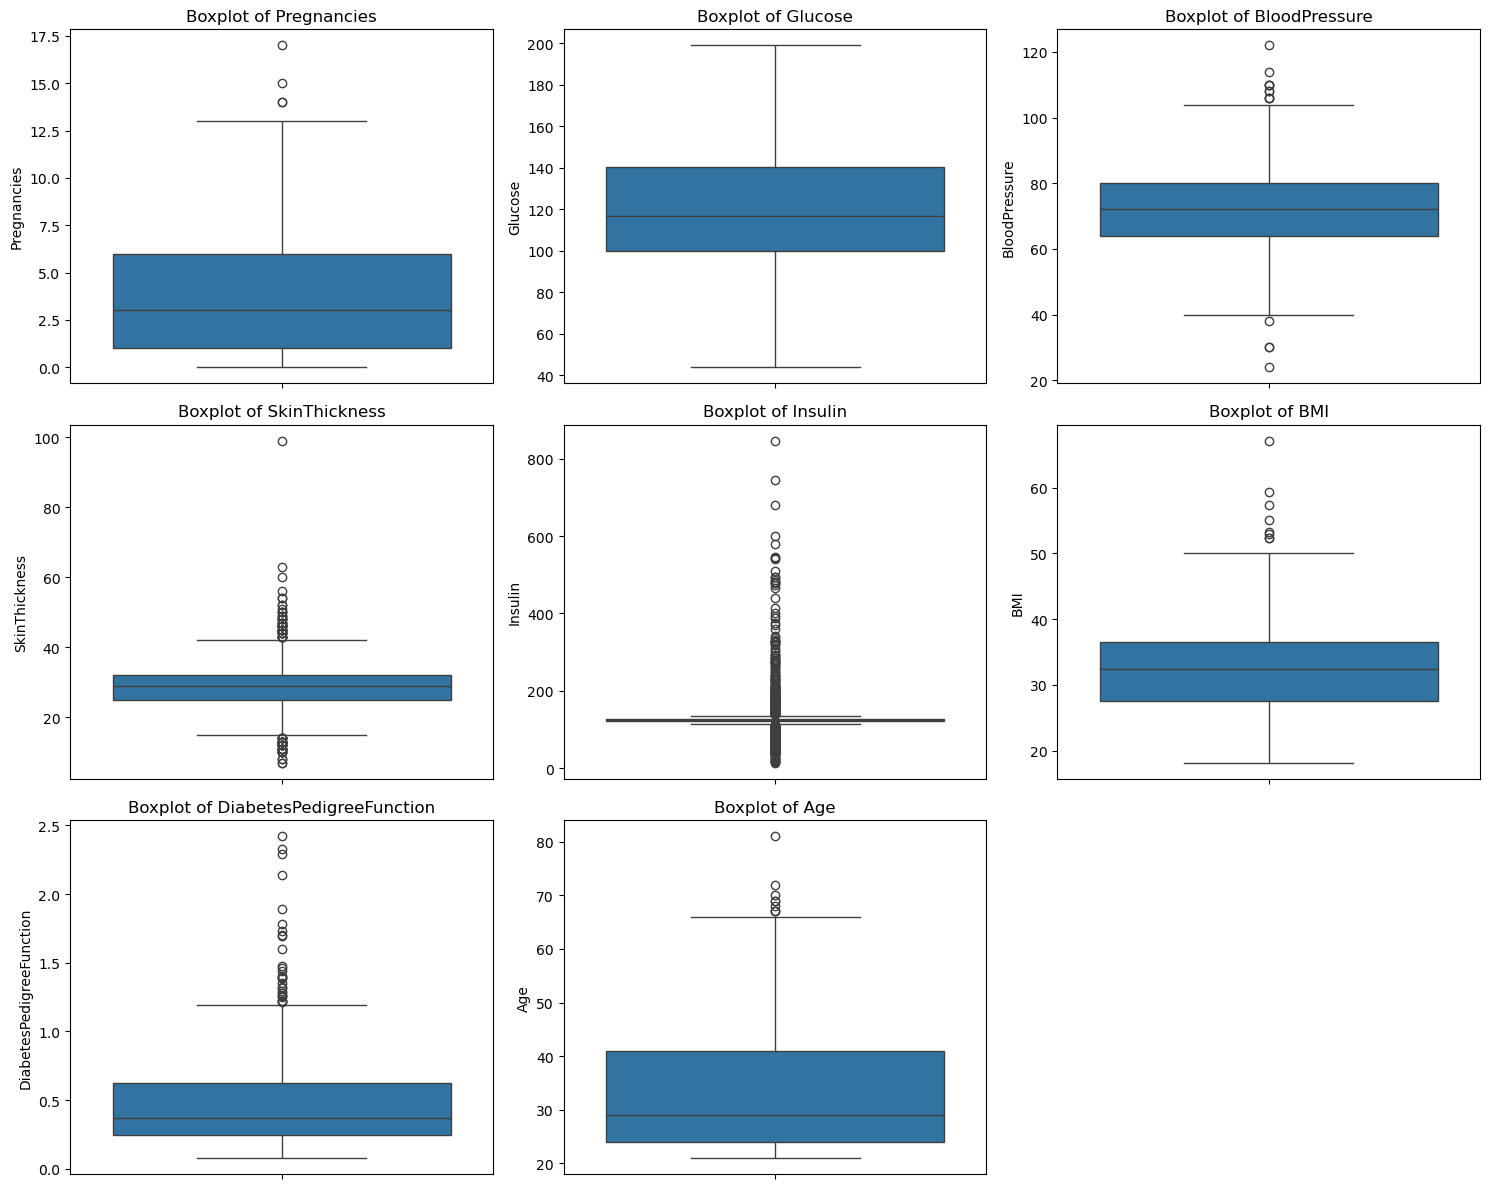

In [50]:
num_cols = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]
plt.figure(figsize=(15,12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()

#### Outlier Analysis
* Histograms provided an initial understanding of skewed distributions and potential extreme values.
* Boxplots were further used to identify statistical outliers using the IQR method.
* Significant outliers were observed in features such as Insulin, DiabetesPedigreeFunction, BMI, and Age.

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [52]:
df_encode = df.copy()

In [53]:
df_encode.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [54]:
X = df_encode.drop('Outcome',axis=1)
y = df_encode['Outcome']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [56]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [57]:
models = {
    "Logistic Regression" : LogisticRegression(),
    " Naive Bayes" : GaussianNB(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Support Vector Machine" : SVC(probability=True),
    "KNN" : KNeighborsClassifier()
}

In [58]:
results = []

In [59]:
for name , model in models.items():
    model.fit(X_train_scaled,y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'F1 Score': round(f1, 4)
    })

In [60]:
results

[{'Model': 'Logistic Regression', 'Accuracy': 0.7662, 'F1 Score': 0.6538},
 {'Model': ' Naive Bayes', 'Accuracy': 0.7597, 'F1 Score': 0.6542},
 {'Model': 'Decision Tree', 'Accuracy': 0.6688, 'F1 Score': 0.5405},
 {'Model': 'Support Vector Machine', 'Accuracy': 0.7468, 'F1 Score': 0.6214},
 {'Model': 'KNN', 'Accuracy': 0.6688, 'F1 Score': 0.5565}]

* Initially, baseline models were trained using default parameters to evaluate performance. Since Logistic Regression achieved moderate accuracy, hyperparameter tuning was performed to optimize model settings and improve generalization. Further, Random Forest was introduced because it handles nonlinear relationships, feature interactions, and outliers more effectively than simpler linear models.

### HyperParameter Tuning

### Logistic Regression

In [61]:
from sklearn.model_selection import GridSearchCV

In [62]:
logistic = LogisticRegression()

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(
    logistic,
    param_grid_lr,
    cv=5,
    scoring='f1'
)

grid_lr.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             scoring='f1')

In [64]:
grid_lr.cv_results_

{'mean_fit_time': array([0.00073791, 0.00325685, 0.        , 0.00165954, 0.00197496,
        0.00070724, 0.00330305, 0.        , 0.00329041, 0.00120912]),
 'std_fit_time': array([0.00147581, 0.00398905, 0.        , 0.00331907, 0.00321655,
        0.00141449, 0.00404656, 0.        , 0.00403161, 0.00098724]),
 'mean_score_time': array([0.00424061, 0.00165133, 0.00490599, 0.00164056, 0.00376277,
        0.00160804, 0.00160446, 0.00485477, 0.00156794, 0.00368533]),
 'std_score_time': array([0.00371064, 0.00330267, 0.00400679, 0.00328112, 0.00465373,
        0.00321608, 0.00320892, 0.00397085, 0.00313587, 0.00357877]),
 'param_C': masked_array(data=[0.01, 0.01, 0.1, 0.1, 1.0, 1.0, 10.0, 10.0, 100.0,
                    100.0],
              mask=[False, False, False, False, False, False, False, False,
                    False, False],
        fill_value=1e+20),
 'param_penalty': masked_array(data=['l1', 'l2', 'l1', 'l2', 'l1', 'l2', 'l1', 'l2', 'l1',
                    'l2'],
            

In [67]:
log_results = pd.DataFrame(grid_lr.cv_results_)

In [68]:
log_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_penalty,param_solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000738,0.001476,0.004241,0.003711,0.01,l1,liblinear,"{'C': 0.01, 'penalty': 'l1', 'solver': 'liblin...",0.615385,0.659794,0.631579,0.610526,0.600000,0.623457,0.020828,8
1,0.003257,0.003989,0.001651,0.003303,0.01,l2,liblinear,"{'C': 0.01, 'penalty': 'l2', 'solver': 'liblin...",0.609756,0.683544,0.602410,0.602410,0.649351,0.629494,0.032163,2
2,0.000000,0.000000,0.004906,0.004007,0.10,l1,liblinear,"{'C': 0.1, 'penalty': 'l1', 'solver': 'libline...",0.600000,0.675676,0.641026,0.578947,0.640000,0.627130,0.033979,4
3,0.001660,0.003319,0.001641,0.003281,0.10,l2,liblinear,"{'C': 0.1, 'penalty': 'l2', 'solver': 'libline...",0.592593,0.693333,0.607595,0.589744,0.648649,0.626383,0.039536,5
4,0.001975,0.003217,0.003763,0.004654,1.00,l1,liblinear,"{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}",0.600000,0.693333,0.615385,0.586667,0.657534,0.630584,0.039393,1
5,0.000707,0.001414,0.001608,0.003216,1.00,l2,liblinear,"{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}",0.592593,0.693333,0.615385,0.586667,0.657534,0.629102,0.040635,3
6,0.003303,0.004047,0.001604,0.003209,10.00,l1,liblinear,"{'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}",0.592593,0.675676,0.615385,0.586667,0.657534,0.625571,0.035319,6
7,0.000000,0.000000,0.004855,0.003971,10.00,l2,liblinear,"{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}",0.592593,0.675676,0.615385,0.586667,0.657534,0.625571,0.035319,6
8,0.003290,0.004032,0.001568,0.003136,100.00,l1,liblinear,"{'C': 100, 'penalty': 'l1', 'solver': 'libline...",0.592593,0.675676,0.597403,0.586667,0.657534,0.621974,0.037046,9
9,0.001209,0.000987,0.003685,0.003579,100.00,l2,liblinear,"{'C': 100, 'penalty': 'l2', 'solver': 'libline...",0.592593,0.675676,0.597403,0.586667,0.657534,0.621974,0.037046,9


In [69]:
log_results[['param_C','param_penalty','param_solver','mean_test_score']]

,param_C,param_penalty,param_solver,mean_test_score
0,0.01,l1,liblinear,0.623457
1,0.01,l2,liblinear,0.629494
2,0.10,l1,liblinear,0.627130
3,0.10,l2,liblinear,0.626383
4,1.00,l1,liblinear,0.630584
5,1.00,l2,liblinear,0.629102
6,10.00,l1,liblinear,0.625571
7,10.00,l2,liblinear,0.625571
8,100.00,l1,liblinear,0.621974
9,100.00,l2,liblinear,0.621974


In [70]:
log_model = LogisticRegression(C=1,penalty='l1',solver='liblinear')

In [71]:
log_model.fit(X_train_scaled,y_train)

LogisticRegression(C=1, penalty='l1', solver='liblinear')

In [72]:
y_pred_lr = log_model.predict(X_test_scaled)

In [73]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Accuracy: 0.7727272727272727
F1 Score: 0.6601941747572816


### Conclusion
* Logistic Regression performs consistently well on the dataset.
* Hyperparameter tuning slightly improved both accuracy and F1-score.
* The dataset appears to have moderately linear decision boundaries.

## Random forest

In [74]:
from sklearn.ensemble import RandomForestClassifier

In [75]:
rf = RandomForestClassifier(random_state=42)

In [76]:
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [77]:
y_pred_rf = rf.predict(X_test)

In [78]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.7727272727272727
F1 Score: 0.6902654867256637


#### HyperParameter Tuning Random Forest

In [79]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

grid_rf.cv_results_

In [80]:
rf_results = pd.DataFrame(grid_rf.cv_results_)

In [81]:
rf_results=rf_results[['param_n_estimators','param_max_depth','param_min_samples_split','param_min_samples_leaf','param_max_features','mean_test_score']]

In [82]:
rf_model = RandomForestClassifier(n_estimators=200,max_depth=10,min_samples_split=2,min_samples_leaf=1,max_features='log2',
    random_state=42)

In [83]:
rf_model.fit(X_train,y_train)

RandomForestClassifier(max_depth=10, max_features='log2', n_estimators=200,
                       random_state=42)

In [84]:
y_pred_ran = rf_model.predict(X_test)

In [85]:
print("Accuracy:", accuracy_score(y_test, y_pred_ran))
print("F1 Score:", f1_score(y_test, y_pred_ran))

Accuracy: 0.7467532467532467
F1 Score: 0.6608695652173913


* Hyperparameter tuning was applied to Random Forest using GridSearchCV. Although cross-validation performance improved during tuning, the tuned model showed slightly lower performance on the held-out test set compared to the default Random Forest model. Therefore, the default Random Forest model was selected as the final model due to its superior test accuracy and F1-score.

### XGBoost

In [86]:
from xgboost import XGBClassifier

In [87]:
xgb = XGBClassifier(random_state=42,eval_metric='logloss')
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [88]:
y_pred_xg = xgb.predict(X_test)

In [89]:
print("Accuracy:", accuracy_score(y_test, y_pred_xg))
print("F1 Score:", f1_score(y_test, y_pred_xg))

Accuracy: 0.7337662337662337
F1 Score: 0.6611570247933884


### Hyperparameter tuning of XGBoost

In [90]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_xgb.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200]},
             scoring='f1')

In [91]:
grid_xgb.cv_results_

{'mean_fit_time': array([0.07064958, 0.12538776, 0.1772737 , 0.29301119, 0.25647755,
        0.4340754 , 0.06913295, 0.15351844, 0.14943233, 0.20513983,
        0.15217104, 0.24675894, 0.08516455, 0.11329155, 0.09701548,
        0.16501122, 0.12191548, 0.18186827]),
 'std_fit_time': array([0.0038427 , 0.01727746, 0.03538455, 0.08399154, 0.07366072,
        0.03908814, 0.00949332, 0.03719797, 0.01826188, 0.03215351,
        0.02537182, 0.02618141, 0.01652542, 0.00284111, 0.00495067,
        0.00532849, 0.00831016, 0.00694081]),
 'mean_score_time': array([0.01082296, 0.01532683, 0.02941933, 0.01262074, 0.0122931 ,
        0.01029425, 0.01089058, 0.02124643, 0.01412725, 0.01246724,
        0.01407137, 0.01404524, 0.01341462, 0.01082969, 0.01155529,
        0.01091299, 0.01394029, 0.00916748]),
 'std_score_time': array([0.00067469, 0.00973122, 0.00954521, 0.00248109, 0.00325266,
        0.00137123, 0.00177197, 0.00710504, 0.00464874, 0.00126762,
        0.00679247, 0.00216423, 0.00511281, 

In [92]:
xgb_results = pd.DataFrame(grid_xgb.cv_results_)

In [93]:
xgb_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.070650,0.003843,0.010823,0.000675,0.01,3,100,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",0.372881,0.676471,0.588235,0.507042,0.571429,0.543212,0.100898,18
1,0.125388,0.017277,0.015327,0.009731,0.01,3,200,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",0.641975,0.717949,0.586667,0.552632,0.621622,0.624169,0.055932,15
2,0.177274,0.035385,0.029419,0.009545,0.01,5,100,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est...",0.550725,0.608696,0.605263,0.506667,0.571429,0.568556,0.037723,17
3,0.293011,0.083992,0.012621,0.002481,0.01,5,200,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est...",0.634146,0.675325,0.658537,0.592593,0.602740,0.632668,0.031600,12
4,0.256478,0.073661,0.012293,0.003253,0.01,7,100,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est...",0.567568,0.657534,0.578947,0.513514,0.555556,0.574624,0.046991,16
5,0.434075,0.039088,0.010294,0.001371,0.01,7,200,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est...",0.634146,0.700000,0.682353,0.556962,0.613333,0.637359,0.050989,10
6,0.069133,0.009493,0.010891,0.001772,0.10,3,100,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.688889,0.700000,0.658824,0.600000,0.641026,0.657748,0.035695,1
7,0.153518,0.037198,0.021246,0.007105,0.10,3,200,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.659091,0.682927,0.642857,0.611765,0.641975,0.647723,0.023316,6
8,0.149432,0.018262,0.014127,0.004649,0.10,5,100,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.674419,0.729412,0.644444,0.609756,0.625000,0.656606,0.042331,2
9,0.205140,0.032154,0.012467,0.001268,0.10,5,200,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.651163,0.700000,0.645161,0.619048,0.650000,0.653074,0.026213,4


In [94]:
xgb_results[['param_n_estimators','param_learning_rate','param_max_depth','mean_test_score']]

,param_n_estimators,param_learning_rate,param_max_depth,mean_test_score
0,100,0.01,3,0.543212
1,200,0.01,3,0.624169
2,100,0.01,5,0.568556
3,200,0.01,5,0.632668
4,100,0.01,7,0.574624
5,200,0.01,7,0.637359
6,100,0.10,3,0.657748
7,200,0.10,3,0.647723
8,100,0.10,5,0.656606
9,200,0.10,5,0.653074


In [95]:
XGB_model = XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,eval_metric='logloss',random_state=42)

In [96]:
XGB_model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [97]:
y_pred_xgb = XGB_model.predict(X_test)

In [98]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))

Accuracy: 0.7272727272727273
F1 Score: 0.631578947368421


* Although hyperparameter tuning was applied to Random Forest and XGBoost, the default Random Forest classifier achieved the best overall performance on the test dataset with the highest F1-score and stable accuracy. Therefore, the default Random Forest model was selected as the final model for diabetes prediction.

## Final Project Conclusion
* During the experimentation phase, additional feature selection was performed by removing the columns SkinThickness and DiabetesPedigreeFunction, as these features showed comparatively weaker correlation with the target variable during exploratory data analysis and heatmap evaluation.
* After removing these features, multiple machine learning models including Logistic Regression, Random Forest, and XGBoost were retrained and evaluated using Accuracy and F1-score metrics. Hyperparameter tuning was also applied to further optimize model performance.
* However, the experimental results indicated that removing these features did not improve the overall model performance. In several cases, both Accuracy and F1-score slightly decreased after feature removal and tuning. Among all evaluated models, the default Random Forest classifier consistently achieved the best balance between predictive accuracy and F1-score on the original dataset containing all features.
* Therefore, the original dataset with all features was retained, and the default  Random Forest model  was selected as the final model for diabetes prediction due to its stable performance, better generalization capability, and superior classification results compared to other tested approaches.

#### Model Seralization

In [99]:
import joblib

In [100]:
joblib.dump(rf,'diabetes_model.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']